# --- Notebook : Modèle SVM - Cas de Tests de Régression ---

In [1]:
# --- Notebook : Modèle Linéaire - Cas de Tests de Régression ---
import ctypes
import numpy as np
from numpy.ctypeslib import ndpointer
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# === Chargement de la bibliothèque Rust compilée ===
lib = ctypes.CDLL("../target/release/mymodel.dll")

In [3]:
# === FFI declarations ===

lib.create_svm_rbf_classifier.argtypes = [
    ctypes.c_size_t,   # n_support
    ctypes.c_double,   # gamma
    ctypes.c_double,   # C
    ctypes.c_double,   # learning_rate
    ctypes.c_size_t    # epochs
]
lib.create_svm_rbf_classifier.restype = ctypes.c_void_p

lib.train_svm_rbf_classifier.argtypes = [
    ctypes.c_void_p,
    ndpointer(ctypes.c_double, flags="C_CONTIGUOUS"),  # X_flat
    ndpointer(ctypes.c_double, flags="C_CONTIGUOUS"),  # Y
    ctypes.c_size_t,
    ctypes.c_size_t
]

lib.predict_svm_rbf_classifier.argtypes = [
    ctypes.c_void_p,
    ndpointer(ctypes.c_double, flags="C_CONTIGUOUS"),
    ctypes.c_size_t
]
lib.predict_svm_rbf_classifier.restype = ctypes.c_double

In [4]:
import matplotlib.pyplot as plt

def test_svm_classifier_rbf(lib, X, Y, name, n_support=10, gamma=1.0, C=1.0, lr=0.01, epochs=1000):
    print(f"\n--- {name} ---")

    # Sécurité et conversion
    X = np.array(X, dtype=np.float64, order='C')
    Y = np.array(Y, dtype=np.float64, order='C')
    X_flat = X.flatten()

    n_samples, n_features = X.shape

    # Création du modèle
    model = lib.create_svm_rbf_classifier(n_support, gamma, C, lr, epochs)

    # Entraînement
    lib.train_svm_rbf_classifier(model, X_flat, Y, n_samples, n_features)

    # Prédictions
    predictions = []
    for i in range(n_samples):
        x = np.array(X[i], dtype=np.float64, order='C')
        pred = lib.predict_svm_rbf_classifier(model, x, n_features)
        predictions.append(pred)
        print(f"Exemple {i} : Prédit = {pred:.1f}, Vrai = {Y[i]:.1f}")

    predictions = np.array(predictions)

    # Visualisation
    if n_features == 2:
        plt.figure()
        plt.title(name)
        plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='bwr', marker='o', label="Vrai", alpha=0.5)
        plt.scatter(X[:, 0], X[:, 1], c=predictions, cmap='bwr', marker='x', label="Prédit", alpha=0.8)
        plt.legend(["Vrai", "Prédit"])
        plt.grid(True)
        plt.show()
    else:
        plt.figure()
        plt.title(name)
        plt.plot(Y, label="Vrai", marker='o', color='blue')
        plt.plot(predictions, label="Prédit", marker='x', color='red')
        plt.grid(True)
        plt.legend()
        plt.show()


# Linear simple


--- SVM Classifier RBF - Linear Simple ---
Exemple 0 : Prédit = 1.0, Vrai = 1.0
Exemple 1 : Prédit = 1.0, Vrai = 1.0
Exemple 2 : Prédit = 1.0, Vrai = 1.0
Exemple 3 : Prédit = 1.0, Vrai = -1.0
Exemple 4 : Prédit = 1.0, Vrai = -1.0
Exemple 5 : Prédit = 1.0, Vrai = -1.0


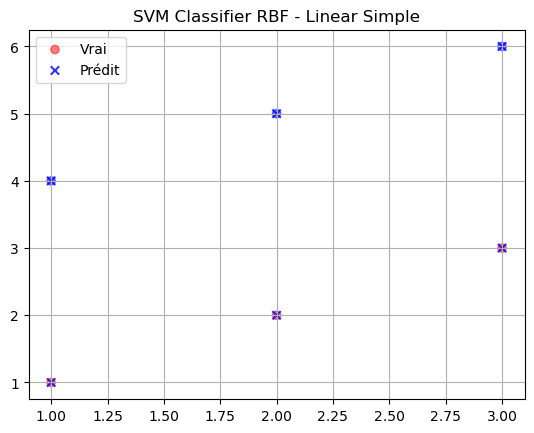

In [ ]:
# === Cas de test : Linear Simple Classification ===
X_cls1 = np.array([
    [1, 1], [2, 2], [3, 3],      # classe +1
    [1, 4], [2, 5], [3, 6]       # classe -1
])
Y_cls1 = np.array([1, 1, 1, -1, -1, -1], dtype=np.float64)

test_svm_classifier_rbf(lib, X_cls1, Y_cls1, "SVM Classifier RBF - Linear Simple", n_support=6, gamma=1.0, C=1.0, lr=0.05, epochs=1000 )


# Linear Multiple


--- SVM Classifier RBF - Classification - Linear Multiple ---
Exemple 0 : Prédit = 1.0, Vrai = 1.0
Exemple 1 : Prédit = 1.0, Vrai = 1.0
Exemple 2 : Prédit = 1.0, Vrai = 1.0
Exemple 3 : Prédit = 1.0, Vrai = 1.0
Exemple 4 : Prédit = 1.0, Vrai = 1.0
Exemple 5 : Prédit = 1.0, Vrai = 1.0
Exemple 6 : Prédit = 1.0, Vrai = -1.0
Exemple 7 : Prédit = 1.0, Vrai = -1.0
Exemple 8 : Prédit = 1.0, Vrai = -1.0
Exemple 9 : Prédit = 1.0, Vrai = -1.0
Exemple 10 : Prédit = 1.0, Vrai = -1.0
Exemple 11 : Prédit = 1.0, Vrai = -1.0


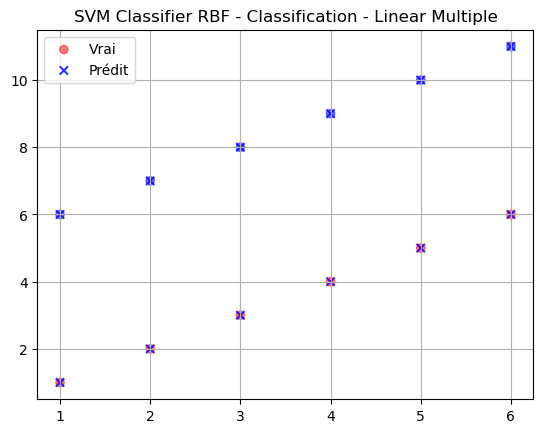

In [6]:
# === Cas 2 : Linear Multiple ===
X_cls2 = np.array([
    [1, 1], [2, 2], [3, 3],
    [4, 4], [5, 5], [6, 6],
    [1, 6], [2, 7], [3, 8],
    [4, 9], [5, 10], [6, 11]
])
Y_cls2 = np.array([1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1])

test_svm_classifier_rbf(lib, X_cls2, Y_cls2, "SVM Classifier RBF - Classification - Linear Multiple", n_support=6, gamma=1.0, C=1.0, lr=0.05, epochs=1000 )

# XOR


--- SVM Classifier RBF - Classification - XOR ---
Exemple 0 : Prédit = 1.0, Vrai = 1.0
Exemple 1 : Prédit = 1.0, Vrai = 1.0
Exemple 2 : Prédit = 1.0, Vrai = 1.0
Exemple 3 : Prédit = 1.0, Vrai = 1.0
Exemple 4 : Prédit = 1.0, Vrai = 1.0
Exemple 5 : Prédit = 1.0, Vrai = 1.0
Exemple 6 : Prédit = 1.0, Vrai = -1.0
Exemple 7 : Prédit = 1.0, Vrai = -1.0
Exemple 8 : Prédit = 1.0, Vrai = -1.0
Exemple 9 : Prédit = 1.0, Vrai = -1.0
Exemple 10 : Prédit = 1.0, Vrai = -1.0
Exemple 11 : Prédit = 1.0, Vrai = -1.0


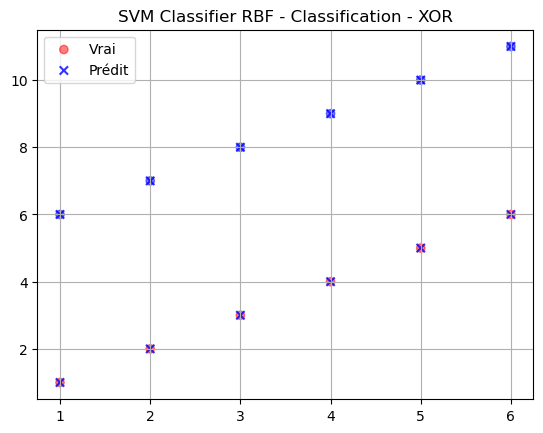

In [8]:
# === Cas 3 : XOR (Non-linéaire) ===
X_xor = np.array([
    [0, 0], [0, 1], [1, 0], [1, 1]
])
Y_xor = np.array([-1, 1, 1, -1])

test_svm_classifier_rbf(lib, X_cls2, Y_cls2, "SVM Classifier RBF - Classification - XOR", n_support=6, gamma=1.0, C=1.0, lr=0.05, epochs=1000 )

#   Cross


--- SVM Classifier RBF - Classification - Cross ---
Exemple 0 : Prédit = 1.0, Vrai = 1.0
Exemple 1 : Prédit = 1.0, Vrai = 1.0
Exemple 2 : Prédit = 1.0, Vrai = 1.0
Exemple 3 : Prédit = 1.0, Vrai = 1.0
Exemple 4 : Prédit = 1.0, Vrai = 1.0
Exemple 5 : Prédit = 1.0, Vrai = 1.0
Exemple 6 : Prédit = 1.0, Vrai = -1.0
Exemple 7 : Prédit = 1.0, Vrai = -1.0
Exemple 8 : Prédit = 1.0, Vrai = -1.0
Exemple 9 : Prédit = 1.0, Vrai = -1.0
Exemple 10 : Prédit = 1.0, Vrai = -1.0
Exemple 11 : Prédit = 1.0, Vrai = -1.0


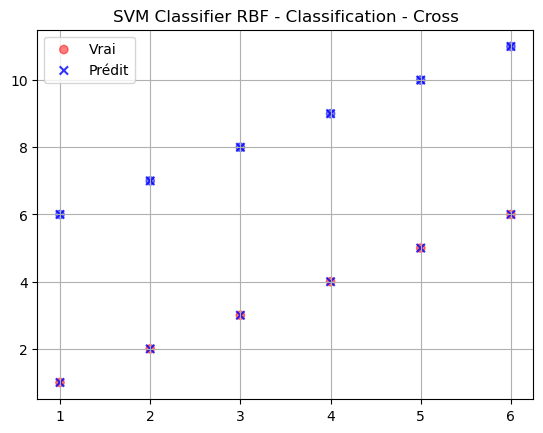

In [9]:
# === Cas 4 : Cross  ===
X_cross = np.array([
    [1, 0], [2, 0], [3, 0],
    [0, 1], [0, 2], [0, 3],
    [1, 1], [2, 2], [3, 3]
])
Y_cross = np.array([1, 1, 1, 1, 1, 1, -1, -1, -1])

test_svm_classifier_rbf(lib, X_cls2, Y_cls2, "SVM Classifier RBF - Classification - Cross", n_support=6, gamma=1.0, C=1.0, lr=0.05, epochs=1000 )